# smelt-bench

In [1]:
import os

if "COLAB_GPU" in os.environ:
    if not os.path.exists("smelt"):
        os.system("git clone https://github.com/PritRaj1/smelt.git")
    os.chdir("smelt")
    os.system("pip install -q -e '.[bench]'")
    os.system("python -c 'from smelt._clib import load_lib; load_lib()'")
else:
    os.chdir(os.path.join(os.path.dirname(os.getcwd())))

print(f"cwd: {os.getcwd()}")

cwd: /home/pritmanguy/Work/smelt


In [2]:
MODEL = "gpt2"
OUT = "benches/bench_results.json"
PP = 8
TG = 16

!rm -f {OUT}

In [3]:
!python benches/bench.py run -m smelt --model {MODEL} -p {PP} -n {TG} -o {OUT}

method: smelt  model: gpt2
pp=8 tg=16  hw: {'cpu': 'x86_64', 'cores': 6, 'ram_gb': 16.4, 'gpu': 'NVIDIA GeForce GTX 1650', 'vram_gb': 3.9}



`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights: 100%|██████████████████████| 148/148 [00:00<00:00, 6839.54it/s]


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


pp8: 161.1 tok/s
tg16: 49.5 tok/s
mem:   972 MB

appended to benches/bench_results.json


In [4]:
!python benches/bench.py run -m hf-gpu --model {MODEL} -p {PP} -n {TG} -o {OUT}

method: hf-gpu  model: gpt2
pp=8 tg=16  hw: {'cpu': 'x86_64', 'cores': 6, 'ram_gb': 16.4, 'gpu': 'NVIDIA GeForce GTX 1650', 'vram_gb': 3.9}



`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|                                  | 0/148 [00:00<?, ?it/s]

Loading weights: 100%|██████████████████████| 148/148 [00:00<00:00, 7546.19it/s]


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


pp8: 198.0 tok/s
tg16: 101.2 tok/s
mem:   255 MB

appended to benches/bench_results.json


In [5]:
!python benches/bench.py plot {OUT}

saved benches/benchmark.png

method                 pp tok/s   tg tok/s     mem MB
-----------------------------------------------------
smelt                     161.1       49.5        972
hf-gpu                    198.0      101.2        255


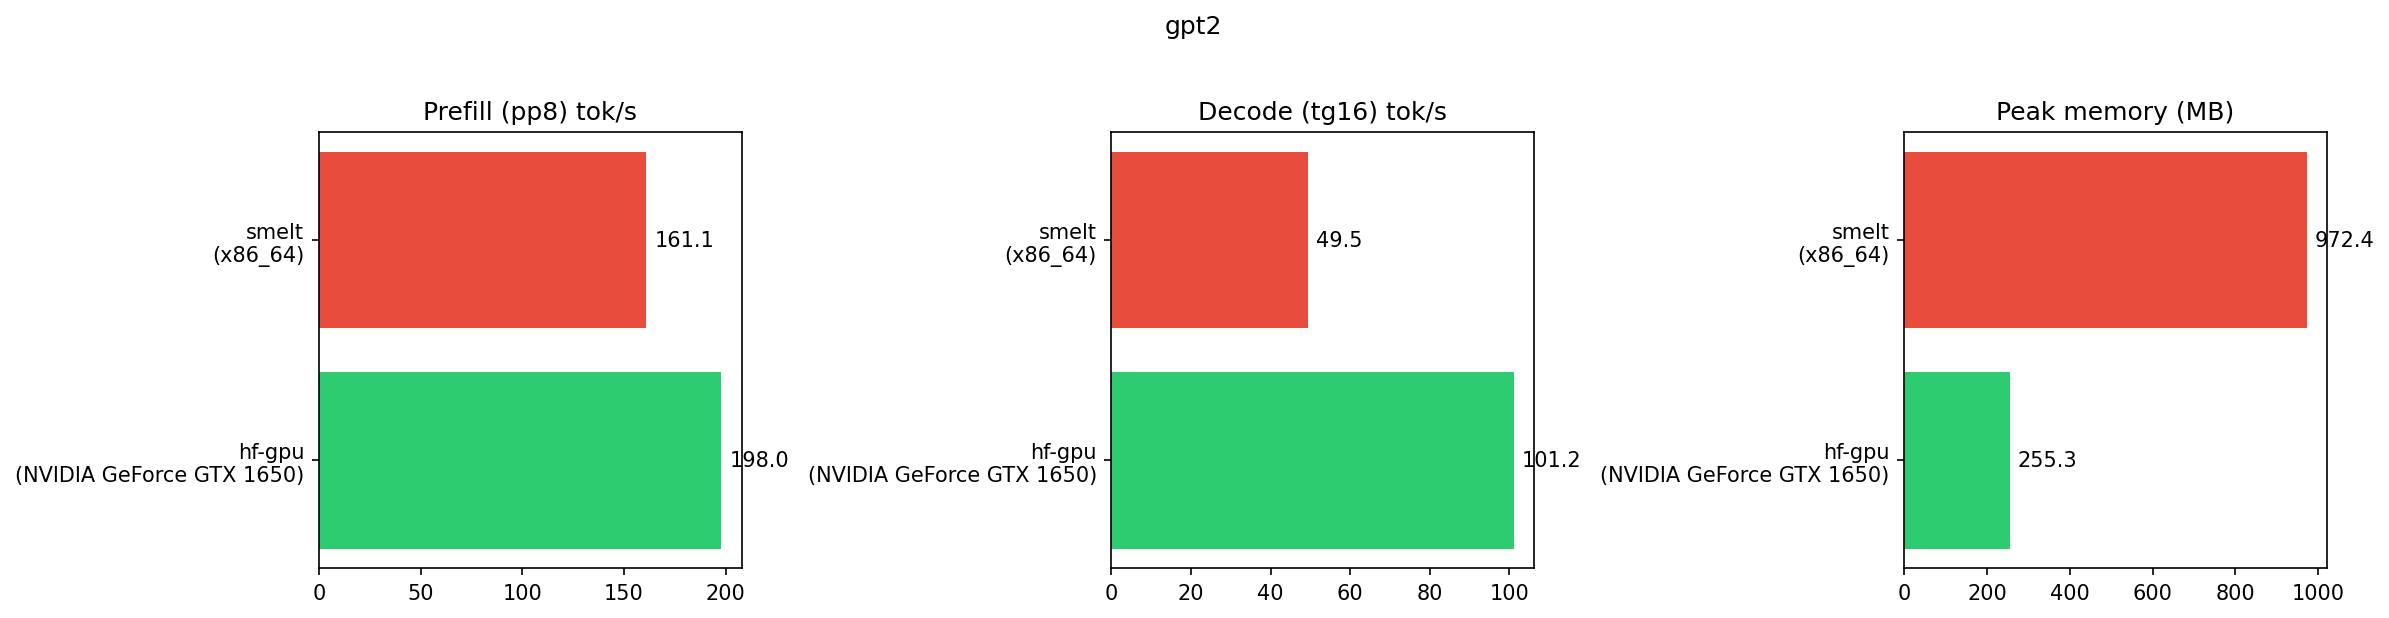

In [6]:
from IPython.display import Image

Image("benches/benchmark.png")